# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import os

print("-> [SUKSES] Semua library analisis data berhasil di-import!")

-> [SUKSES] Semua library analisis data berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
df = pd.read_csv('heart_raw.csv')

# Menampilkan dimensi data dan 5 baris pertama
print(f"Dimensi Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("=== 5 BARIS PERTAMA DATASET HEART ===")
display(df.head())

Dimensi Dataset: 918 baris, 12 kolom

=== 5 BARIS PERTAMA DATASET HEART ===


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== INFORMASI STRUKTUR DATA DAN TIPE DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

=== MENGECEK JUMLAH MISSING VALUES ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS       

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000



=== Analisis Visual - Grafik Distribusi Kelas Target ===


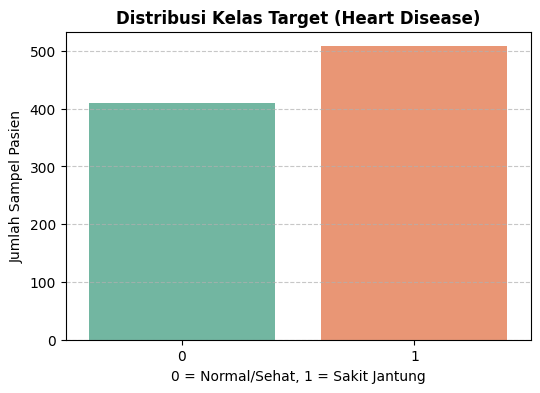

In [4]:
print("=== INFORMASI STRUKTUR DATA DAN TIPE DATA ===")
df.info()

print("\n=== MENGECEK JUMLAH MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== RINGKASAN STATISTIK DATA NUMERIK ===")
display(df.describe())

print("\n=== Analisis Visual - Grafik Distribusi Kelas Target ===")
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df, hue='HeartDisease',palette='Set2', legend=False)
plt.title('Distribusi Kelas Target (Heart Disease)', fontsize=12, fontweight='bold')
plt.xlabel('0 = Normal/Sehat, 1 = Sakit Jantung')
plt.ylabel('Jumlah Sampel Pasien')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
print("=== MEMULAI TAHAP DATA PREPROCESSING ===")

# 1. Memisahkan Fitur (X) dan Target (y)
# Kolom 'HeartDisease' adalah target yang mau ditebak
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# 2. Encoding Data Kategorikal (Mengubah Teks Teks Menjadi Angka Otomatis)
# Menggunakan pd.get_dummies untuk melakukan One-Hot Encoding pada kolom teks
X_encoded = pd.get_dummies(X, drop_first=True)
print("-> [SUKSES] Encoding selesai. Semua kolom teks sudah berubah jadi angka biner.")

# 3. Normalisasi / Standarisasi Fitur Numerik
# Kolom-kolom angka yang jomplang nilainya disamakan skalanya menggunakan StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("-> [SUKSES] Normalisasi data numerik selesai menggunakan StandardScaler.")

# 4. Memisahkan Data Menjadi Train Set dan Test Set (80% : 20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"-> [INFO] Data berhasil dibagi: Train Set = {X_train.shape[0]} baris, Test Set = {X_test.shape[0]} baris.")

# 5. Menyimpan Hasil Preprocessing Secara Fisik
# Membuat folder penyimpan jika belum ada
output_dir = '../preprocessing/heart_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Menggabungkan kembali X dan y untuk disimpan sebagai file siap pakai
train_clean = X_train.copy()
train_clean['HeartDisease'] = y_train

test_clean = X_test.copy()
train_clean['HeartDisease'] = y_test

# Menyimpan ke format CSV bersih
train_clean.to_csv(f'{output_dir}/train_clean.csv', index=False)
train_clean.to_csv(f'{output_dir}/test_clean.csv', index=False)

print(f"\n-> [SUKSES REKOR] Data bersih berhasil disimpan di folder: '{output_dir}/'")


=== MEMULAI TAHAP DATA PREPROCESSING ===
-> [SUKSES] Encoding selesai. Semua kolom teks sudah berubah jadi angka biner.
-> [SUKSES] Normalisasi data numerik selesai menggunakan StandardScaler.
-> [INFO] Data berhasil dibagi: Train Set = 734 baris, Test Set = 184 baris.

-> [SUKSES REKOR] Data bersih berhasil disimpan di folder: '../preprocessing/heart_preprocessing/'
